# SymPy

In [1]:
import sympy as sp

Simply supported beam deflection with uniformly distributed load:
$$
\Delta = \frac{5wL^4}{384EI}
$$

## Symbols

In [2]:
w, L, E, I = sp.symbols('w L E I',)

## Expressions

In [3]:
Delta = 5*w*L**4/(384*E*I)
Delta

5*L**4*w/(384*E*I)

## Substitutions

In [4]:
w_real = 30E3 # N/m
E_real = 200E9 # Pa
I_real = 41000 * 1E-8 # m^4 UB 457 x 191x 89
L_real = 6
Delta_val = Delta.subs({w: w_real, E: E_real, I: I_real, L: L_real})
Delta_val


0.00617378048780488

## Lambdify

In [5]:
Delta_L = Delta.subs({w: w_real, E: E_real, I: I_real})
Delta_L

4.76371951219512e-6*L**4

In [6]:
deflections = sp.lambdify(L,Delta_L)

In [7]:
# Define deflections as a function, where input is length L
deflection_L_real = deflections(L_real)
deflection_L_real

0.006173780487804876

## Solve

In [8]:
roots = sp.solve(Delta_L-deflection_L_real)
roots = sp.solve(sp.Eq(Delta_L, deflection_L_real), L)
print(f"roots = {roots}")

roots = [-6.00000000000000, 6.00000000000000, -6.0*I, 6.0*I]


In [9]:
[r for r in roots if r.is_real and r > 0]

[6.00000000000000]

## Differentiation

### Beam differentiation

1.  **Load**
    *   $w(x) = -\dfrac{dV(x)}{dx} = -\dfrac{d^2M(x)}{dx^2}$

2.  **Shear**
    *   $V(x) = \dfrac{dM(x)}{dx}$

3.  **Moment**
    *   $M(x) = -EI\,\dfrac{d^2y(x)}{dx^2}$

4.  **Slope**
    *   $\theta(x) = \dfrac{dy(x)}{dx}$

#### Uniformly distributed beam

<img src="beam_UDL.svg" width="300">

For a simply supported beam under UDL: 
* $V(x) = \dfrac{w L}{2} - w x$
* $M(x) = \dfrac{w L}{2}x - \dfrac{w}{2}x^2 \qquad \text{(sagging positive)}$
* $\theta(x) = \dfrac{w}{24EI}\big(4x^3 - 6Lx^2 + L^3\big)$ 
* $y(x) = \dfrac{w}{24EI}(x^4 - 2Lx^3 + L^3x) \qquad \text{(downwards positive)}$


In [14]:
# Define symbols
x, L, w = sp.symbols('x L w', positive=True, real=True)

# Bending moment for SS beam under UDL:
M = (w*L/2)*x - (w*x**2)/2
print("Moment M(x):", M)

# Differentiate moment to get shear:
V = sp.diff(M, x)
print("Shear V(x):", V)

# Differentiate shear to get load:
w = -sp.diff(V, x)
w = -sp.diff(M, x, x)
w = -sp.diff(M, x, 2)
print("Load w(x):", w)


Moment M(x): L*w*x/2 - w*x**2/2
Shear V(x): L*w/2 - w*x
Load w(x): w


## Integration

### Beam direct integration

2.  **Shear**
    *   $V(x) = \int_{0}^{L} -w{dx} + C1$

3.  **Moment**
    *   $M(x) = \int_{0}^{L} V{dx} + C2$

5.  **Slope**
    *   $\theta(x) = \int_{0}^{L} -\frac{M}{EI}{dx} + C3$

5.  **Deflection**
    *   $y(x) = \int_{0}^{L} \theta{dx} + C4$


For a simply supported beam under UDL the following BC can be used: 
* $V(L/2) = 0$.
* $M(0) = 0$
* $\theta(L/2) = 0$
* $y(0) = 0$


In [11]:
# Symbols
x, C1, C2, C3, C4 = sp.symbols('x C1 C2 C3 C4', real=True)
w = sp.symbols('w', positive=True, real=True)

# Integrate V
V = sp.integrate(-w, x) + C1
sol_C1 = sp.solve(sp.Eq(V.subs(x, L/2), 0), (C1),dict=True)[0]
V = sp.simplify(V.subs(sol_C1))

# Integrate M
M = sp.integrate(V, x) + C2
sol_C2 = sp.solve(sp.Eq(M.subs(x, 0), 0), (C2),dict=True)[0]
M = sp.simplify(M.subs(sol_C2))

# Integrate theta
theta = sp.integrate(-M/(E*I), x) + C3
sol_C3 = sp.solve(sp.Eq(theta.subs(x, L/2), 0), (C3),dict=True)[0]
theta = sp.simplify(theta.subs(sol_C3))

# Integrate y
y = sp.integrate(theta, x) + C4
sol_C4 = sp.solve(sp.Eq(y.subs(x, 0), 0), (C4),dict=True)[0]
y = sp.simplify(y.subs(sol_C4))

print(f"V = {V}")
print(f"M = {M}")
print(f"theta = {theta}")
print(f"y = {y}")


V = w*(L - 2*x)/2
M = w*x*(L - x)/2
theta = w*(L**3 - 6*L*x**2 + 4*x**3)/(24*E*I)
y = w*x*(L**3 - 2*L*x**2 + x**3)/(24*E*I)


In [12]:
V_x = sp.lambdify(x,V.subs({w: w_real, E: E_real, I: I_real, L: L_real}))
M_x = sp.lambdify(x,M.subs({w: w_real, E: E_real, I: I_real, L: L_real}))
theta_x = sp.lambdify(x,theta.subs({w: w_real, E: E_real, I: I_real, L: L_real}))
y_x = sp.lambdify(x,y.subs({w: w_real, E: E_real, I: I_real, L: L_real}))

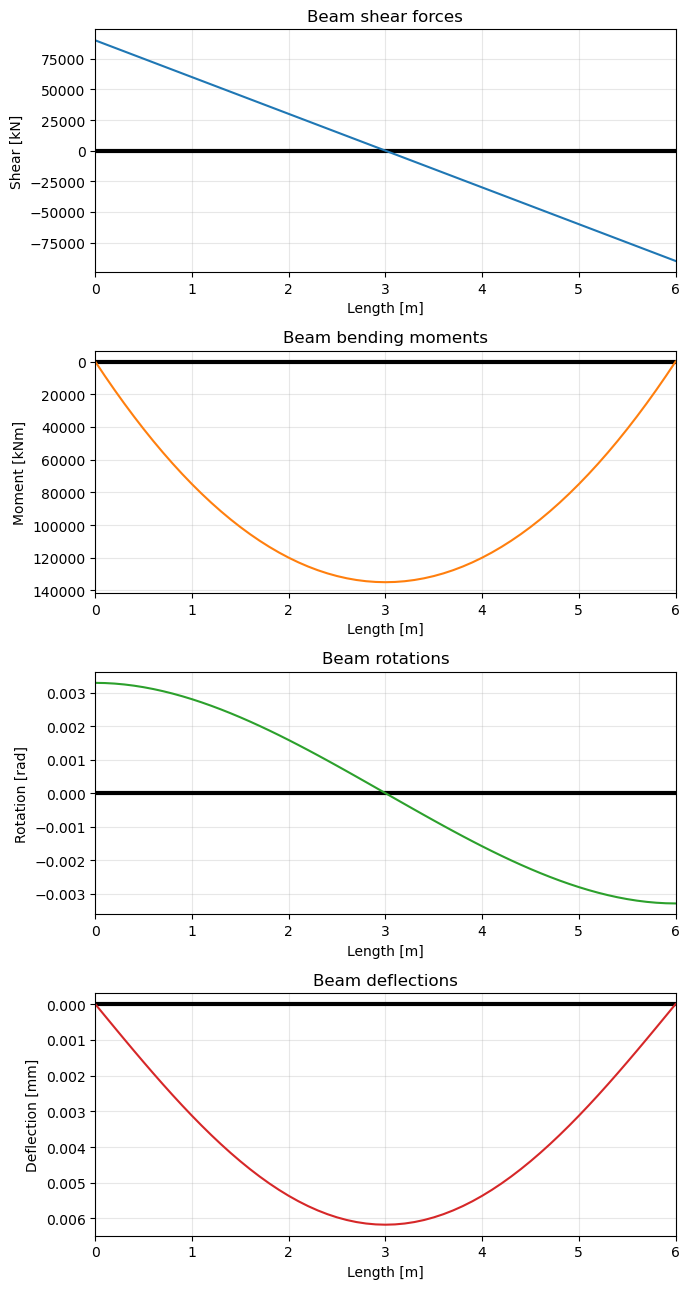

In [19]:
import numpy as np
x_arr = np.linspace(0,L_real,L_real * 10 + 1)
V_arr = np.array([V_x(x) for x in x_arr])
M_arr = np.array([M_x(x) for x in x_arr])
theta_arr = np.array([theta_x(x) for x in x_arr])
y_arr = np.array([y_x(x) for x in x_arr])


from matplotlib import pyplot as plt
fig, ax = plt.subplots(4,1,figsize=(7,13))

ax[0].grid(True, alpha=0.3)
ax[0].plot([0, L_real], [0, 0], color='k', linewidth = 3)
ax[0].plot(x_arr, V_arr, color='C0')
ax[0].set_xlabel("Length [m]")
ax[0].set_ylabel("Shear [kN]")
ax[0].set_xlim([0, L_real])
ax[0].set_title("Beam shear forces")

ax[1].grid(True, alpha=0.3)
ax[1].plot([0, L_real], [0, 0], color='k', linewidth = 3)
ax[1].plot(x_arr, M_arr, color='C1')
ax[1].set_xlabel("Length [m]")
ax[1].set_ylabel("Moment [kNm]")
ax[1].set_xlim([0, L_real])
ax[1].invert_yaxis() # Downwards positive
ax[1].set_title("Beam bending moments")

ax[2].grid(True, alpha=0.3)
ax[2].plot([0, L_real], [0, 0], color='k', linewidth = 3)
ax[2].plot(x_arr, theta_arr, color='C2')
ax[2].set_xlabel("Length [m]")
ax[2].set_ylabel("Rotation [rad]")
ax[2].set_xlim([0, L_real])
ax[2].set_title("Beam rotations")

ax[3].grid(True, alpha=0.3)
ax[3].plot([0, L_real], [0, 0], color='k', linewidth = 3)
ax[3].plot(x_arr, y_arr, color='C3')
ax[3].set_xlabel("Length [m]")
ax[3].set_ylabel("Deflection [mm]")
ax[3].set_xlim([0, L_real])
ax[3].invert_yaxis() # Downwards positive
ax[3].set_title("Beam deflections")

plt.tight_layout()

plt.show()

